In [ ]:
# NeuroLens: Molecular Intelligence for Psychiatric Classification


## Notebook 02: EDA Preprocessing & Batch Correction

**By:** Ali | MSc Neuroscience | SPICED Academy Data Science Bootcamp

**Date:** February 2026

---

## Table of Contents

1. [Step 0: Import Libraries and Load EDA Results](#Step-0)
2. [Step 1: Restrict to Shared Probes (22,277)](#Step-1)
3. [Step 2: Log2 Transform Raw Datasets](#Step-2)
4. [Step 3: Handle GSE21935 Negative Values](#Step-3)
5. [Step 4: Investigate GSE12649 Normalization](#Step-4)
6. [Step 5: Verify All Datasets on Same Scale](#Step-5)
7. [Step 6: Merge All Datasets](#Step-6)
8. [Step 7: ComBat Batch Correction](#Step-7)
9. [Step 8: PCA After Batch Correction](#Step-8)
10. [Step 9: Quality Control (Outlier Detection)](#Step-9)
11. [Step 10: Low-Variance Probe Filtering](#Step-10)
12. [Step 11: Final Preprocessed Data Export](#Step-11)

## Goal of This Notebook
Take the 8 raw datasets from EDA (different scales, different platforms, strong batch effects) and produce ONE clean, batch-corrected, ML-ready DataFrame where:
- All 419 samples are on the same log2 expression scale
- Batch effects between datasets are removed
- Outlier samples are excluded
- Low-information probes are filtered out
- The output is ready for Model and machine learning training in Notebook 03

In [ ]:
## Step 0: Import Libraries and Reload EDA Data

**Why reload?** Each notebook should be self-contained and runnable independently. 
We reload the raw data and repeat the essential EDA steps (parsing, label extraction, GSE21138 exclusion, GSE53987 PFC filtering) 
so this notebook works without running EDA first.

In [2]:
# ---------------------------------------------------------
# Step 0: Import libraries
# ---------------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gzip
import os
from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

pd.set_option('display.max_columns', 20)

print("Libraries loaded.")

Libraries loaded.


In [3]:
# ---------------------------------------------------------
# Step 0b: Reload data from EDA
# ---------------------------------------------------------

DATA_DIR = "../data/raw/"

# --- Parser function (same as EDA) ---
def parse_geo_series_matrix(filepath):
    """Parse a GEO Series Matrix file into metadata dict and expression DataFrame."""
    meta = {'sample_ids': [], 'sample_titles': []}
    
    open_func = gzip.open if filepath.endswith('.gz') else open
    
    # First pass: extract metadata
    with open_func(filepath, 'rt') as f:
        for line in f:
            if line.startswith('!Sample_geo_accession'):
                meta['sample_ids'] = [x.strip().strip('"') for x in line.split('\t')[1:]]
            elif line.startswith('!Sample_title'):
                meta['sample_titles'] = [x.strip().strip('"') for x in line.split('\t')[1:]]
            elif line.startswith('!Sample_characteristics_ch1'):
                parts = [x.strip().strip('"') for x in line.split('\t')[1:]]
                if ':' in parts[0]:
                    key = parts[0].split(':')[0].strip()
                    values = [x.split(':',1)[1].strip() if ':' in x else x for x in parts]
                    meta[key] = values
    
    # Second pass: read expression matrix
    expr = pd.read_csv(filepath, sep='\t', comment='!', index_col=0, low_memory=False)
    expr = expr.apply(pd.to_numeric, errors='coerce')
    expr = expr.loc[expr.index.dropna()]
    expr.index = expr.index.astype(str)
    expr.index.name = 'probe_id'
    
    return meta, expr

# --- Load 7 GEO datasets (GSE21138 excluded during EDA) ---
geo_files = {
    'GSE53987': 'GSE53987_series_matrix.txt.gz',
    'GSE17612': 'GSE17612_series_matrix.txt',
    'GSE21935': 'GSE21935_series_matrix.txt',
    'GSE54568': 'GSE54568_series_matrix.txt',
    'GSE12649': 'GSE12649_series_matrix.txt',
    'GSE5388':  'GSE5388_series_matrix.txt',
    'GSE5389':  'GSE5389_series_matrix.txt',
}

datasets = {}
all_meta = {}

for name, filename in geo_files.items():
    filepath = os.path.join(DATA_DIR, filename)
    meta, expr = parse_geo_series_matrix(filepath)
    datasets[name] = expr
    all_meta[name] = meta
    print(f"  Loaded {name}: {expr.shape[0]} probes x {expr.shape[1]} samples")

# --- Load SMRI Altar C ---
demo = pd.read_csv(os.path.join(DATA_DIR, "study2", "demoAnnTable2.txt"), sep='\t')
expr_smri = pd.read_csv(os.path.join(DATA_DIR, "study2", "rmaExpressionTable2.txt"), sep='\t', index_col=0)

sample_ids = [f"C-{i}" for i in range(1, len(demo) + 1)]
demo['sample_id'] = sample_ids

if 'Study_id' in expr_smri.columns:
    expr_smri = expr_smri.drop(columns=['Study_id'])

expr_smri.columns = sample_ids[:expr_smri.shape[1]]
expr_smri.index = expr_smri.index.astype(str)
expr_smri.index.name = 'probe_id'

datasets['SMRI_AltarC'] = expr_smri
all_meta['SMRI_AltarC'] = {
    'sample_ids': sample_ids,
    'diagnosis': demo['Axis_I_Primary_Dx'].tolist(),
    'age': demo['Age'].tolist(),
    'sex': demo['Sex'].tolist(),
    'brain_ph': demo['Brain_PH'].tolist(),
    'pmi': demo['PMI'].tolist()
}
print(f"  Loaded SMRI_AltarC: {expr_smri.shape[0]} probes x {expr_smri.shape[1]} samples")

# --- Platform map ---
platform_map = {
    'GSE53987': 'GPL570', 'GSE17612': 'GPL570',
    'GSE21935': 'GPL570', 'GSE54568': 'GPL570',
    'GSE12649': 'GPL96', 'GSE5388': 'GPL96', 'GSE5389': 'GPL96',
    'SMRI_AltarC': 'GPL96'
}

# --- Colorblind-friendly palette ---
colors = {'SCZ': '#7B2D8E', 'BD': '#0072B2', 'MDD': '#009E73', 'CTL': '#999999'}

print(f"\nLoaded {len(datasets)} datasets.")

  Loaded GSE53987: 54675 probes x 205 samples
  Loaded GSE17612: 54675 probes x 51 samples
  Loaded GSE21935: 54675 probes x 42 samples
  Loaded GSE54568: 54675 probes x 30 samples
  Loaded GSE12649: 22283 probes x 102 samples
  Loaded GSE5388: 22283 probes x 61 samples
  Loaded GSE5389: 22283 probes x 21 samples
  Loaded SMRI_AltarC: 22283 probes x 44 samples

Loaded 8 datasets.


In [4]:
# ---------------------------------------------------------
# Step 0c: Extract diagnosis labels (same as EDA, corrected)
# ---------------------------------------------------------

all_labels = {}

# GSE53987
labels = {}
for sid, d in zip(all_meta['GSE53987']['sample_ids'], all_meta['GSE53987']['disease state']):
    d_lower = d.lower()
    if 'schizophrenia' in d_lower:   labels[sid] = 'SCZ'
    elif 'bipolar' in d_lower:       labels[sid] = 'BD'
    elif 'depressive' in d_lower:    labels[sid] = 'MDD'
    elif 'control' in d_lower:       labels[sid] = 'CTL'
all_labels['GSE53987'] = labels

# GSE17612
labels = {}
for sid, title in zip(all_meta['GSE17612']['sample_ids'], all_meta['GSE17612']['sample_titles']):
    if '_Scz_' in title:             labels[sid] = 'SCZ'
    elif '_Control_' in title:       labels[sid] = 'CTL'
all_labels['GSE17612'] = labels

# GSE21935
labels = {}
for sid, d in zip(all_meta['GSE21935']['sample_ids'], all_meta['GSE21935']['disease state']):
    if 'schizo' in d.lower():        labels[sid] = 'SCZ'
    elif 'control' in d.lower():     labels[sid] = 'CTL'
all_labels['GSE21935'] = labels

# GSE54568
labels = {}
for sid, d in zip(all_meta['GSE54568']['sample_ids'], all_meta['GSE54568']['disease state']):
    if 'mdd' in d.lower() or 'depress' in d.lower():  labels[sid] = 'MDD'
    elif 'control' in d.lower():                        labels[sid] = 'CTL'
all_labels['GSE54568'] = labels

# GSE12649
labels = {}
for sid, title in zip(all_meta['GSE12649']['sample_ids'], all_meta['GSE12649']['sample_titles']):
    if 'bipolar' in title.lower():         labels[sid] = 'BD'
    elif 'schizophrenia' in title.lower(): labels[sid] = 'SCZ'
    elif 'control' in title.lower():       labels[sid] = 'CTL'
all_labels['GSE12649'] = labels

# GSE5388
labels = {}
for sid, d in zip(all_meta['GSE5388']['sample_ids'], all_meta['GSE5388']['Disease_status']):
    if 'bipolar' in d.lower():       labels[sid] = 'BD'
    elif 'control' in d.lower():     labels[sid] = 'CTL'
all_labels['GSE5388'] = labels

# GSE5389
labels = {}
for sid, d in zip(all_meta['GSE5389']['sample_ids'], all_meta['GSE5389']['Disease_status']):
    if 'bipolar' in d.lower():       labels[sid] = 'BD'
    elif 'control' in d.lower():     labels[sid] = 'CTL'
all_labels['GSE5389'] = labels

# SMRI Altar C
labels = {}
for sid, d in zip(all_meta['SMRI_AltarC']['sample_ids'], all_meta['SMRI_AltarC']['diagnosis']):
    d_lower = d.lower()
    if 'schiz' in d_lower:           labels[sid] = 'SCZ'
    elif 'bp' in d_lower:            labels[sid] = 'BD'
    elif 'depress' in d_lower:       labels[sid] = 'MDD'
    elif 'control' in d_lower:       labels[sid] = 'CTL'
all_labels['SMRI_AltarC'] = labels

print("Diagnosis labels extracted for all 8 datasets.")

Diagnosis labels extracted for all 8 datasets.


In [5]:
# ---------------------------------------------------------
# Step 0d: Apply EDA decisions (PFC only for GSE53987, calculate shared probes)
# ---------------------------------------------------------

# GSE21138: not loaded (excluded during EDA due to probe reduction)
print("GSE21138: not loaded (excluded during EDA)")

# Decision: Keep only PFC from GSE53987
pfc_samples = []
for sid, region in zip(all_meta['GSE53987']['sample_ids'], all_meta['GSE53987']['tissue']):
    if 'Pre-frontal cortex' in region:
        pfc_samples.append(sid)

datasets['GSE53987'] = datasets['GSE53987'][pfc_samples]
all_labels['GSE53987'] = {sid: all_labels['GSE53987'][sid] for sid in pfc_samples}
print(f"GSE53987 filtered to PFC only: {len(pfc_samples)} samples")

# Calculate shared probes
gpl570_probes = None
for name in ['GSE53987', 'GSE17612', 'GSE21935', 'GSE54568']:
    probes = set(datasets[name].index.astype(str))
    if gpl570_probes is None:
        gpl570_probes = probes
    else:
        gpl570_probes = gpl570_probes.intersection(probes)

gpl96_probes = None
for name in ['GSE12649', 'GSE5388', 'GSE5389', 'SMRI_AltarC']:
    probes = set(datasets[name].index.astype(str))
    if gpl96_probes is None:
        gpl96_probes = probes
    else:
        gpl96_probes = gpl96_probes.intersection(probes)

shared_probes = sorted(list(gpl570_probes.intersection(gpl96_probes)))

# Final verification
total = {'SCZ': 0, 'BD': 0, 'MDD': 0, 'CTL': 0}
for name in datasets:
    dx = Counter(all_labels[name].values())
    for cls in total:
        total[cls] += dx.get(cls, 0)

t_all = sum(total.values())

print(f"{'='*50}")
print(f"NOTEBOOK 02 STARTING POINT")
print(f"{'='*50}")
print(f"Datasets:      {len(datasets)}")
print(f"Total samples: {t_all}")
print(f"Shared probes: {len(shared_probes):,}")
print(f"  SCZ: {total['SCZ']}")
print(f"  BD:  {total['BD']}")
print(f"  MDD: {total['MDD']}")
print(f"  CTL: {total['CTL']}")
print(f"{'='*50}")

GSE21138: not loaded (excluded during EDA)
GSE53987 filtered to PFC only: 68 samples
NOTEBOOK 02 STARTING POINT
Datasets:      8
Total samples: 419
Shared probes: 22,277
  SCZ: 112
  BD:  101
  MDD: 43
  CTL: 163


In [ ]:
## Step 1: Restrict to Shared Probes

**Purpose:** Each dataset currently has a different number of probes (22,283 for GPL96 or 54,675 for GPL570). To merge them, we keep only the 22,277 probes that exist in ALL 8 datasets.

**What happens:**
- GPL570 datasets lose ~32,398 probes (54,675 → 22,277)
- GPL96 datasets lose 6 probes (22,283 → 22,277)
- After this step, all 8 datasets have exactly 22,277 rows (probes)

In [6]:
# ---------------------------------------------------------
# Step 1: Restrict all datasets to shared probes
# ---------------------------------------------------------

print(f"Shared probes to keep: {len(shared_probes):,}\n")
print(f"{'Dataset':<15} {'Before':>8} {'After':>8} {'Dropped':>8}")
print("-" * 45)

for name in datasets:
    before = datasets[name].shape[0]
    # Keep only shared probes
    datasets[name] = datasets[name].loc[datasets[name].index.isin(shared_probes)]
    after = datasets[name].shape[0]
    print(f"{name:<15} {before:>8,} {after:>8,} {before - after:>8,}")

# Verify all datasets now have the same number of probes
probe_counts = set(datasets[name].shape[0] for name in datasets)
print(f"\nAll datasets now have {probe_counts.pop():,} probes: {'YES' if len(probe_counts) == 0 else 'NO - PROBLEM!'}")

Shared probes to keep: 22,277

Dataset           Before    After  Dropped
---------------------------------------------
GSE53987          54,675   22,277   32,398
GSE17612          54,675   22,277   32,398
GSE21935          54,675   22,277   32,398
GSE54568          54,675   22,277   32,398
GSE12649          22,283   22,277        6
GSE5388           22,283   22,277        6
GSE5389           22,283   22,277        6
SMRI_AltarC       22,283   22,277        6

All datasets now have 22,277 probes: YES


In [ ]:
## Step 2: Log2 Transform Raw Datasets

**Purpose:** Convert all datasets to the same log2 scale.

**From EDA, we identified three groups:**

| Group | Datasets | Scale | Action |
|-------|----------|-------|--------|
| Already log2 | GSE54568, SMRI Altar C | Values 2-16 | No action needed |
| Raw intensity | GSE53987, GSE17612, GSE5388, GSE5389 | Values 0-30,000 | Apply log2 |
| Special cases | GSE21935 (negative values), GSE12649 (max=526) | Mixed | Handle separately |

**Log2 transformation:** For each value x, compute log₂(x). This compresses the range from 0-30,000 down to 0-15 and 
makes the distribution symmetric. A difference of 1 on log2 scale equals a 2-fold change in gene expression.

**Negative value handling (GSE21935):** log₂ of a negative number is undefined. We clip all values below 1 to 1 before transforming. 
These are low-expression noise values that will likely be removed during low-variance filtering.

In [7]:
# ---------------------------------------------------------
# Step 2a: Log2 transform raw intensity datasets
# ---------------------------------------------------------

already_log2 = ['GSE54568', 'SMRI_AltarC']
needs_log2 = ['GSE53987', 'GSE17612', 'GSE5388', 'GSE5389']

for name in needs_log2:
    before_min = datasets[name].min().min()
    before_max = datasets[name].max().max()
    
    datasets[name] = np.log2(datasets[name])
    
    after_min = datasets[name].min().min()
    after_max = datasets[name].max().max()
    
    print(f"{name}: [{before_min:.1f}, {before_max:.1f}] → log2 → [{after_min:.2f}, {after_max:.2f}]")

print(f"\nSkipped (already log2): {already_log2}")

GSE53987: [4.8, 27649.3] → log2 → [2.27, 14.75]
GSE17612: [0.1, 21711.7] → log2 → [-3.64, 14.41]
GSE5388: [8.3, 19132.2] → log2 → [3.06, 14.22]
GSE5389: [5.9, 16225.6] → log2 → [2.57, 13.99]

Skipped (already log2): ['GSE54568', 'SMRI_AltarC']


In [8]:
# ---------------------------------------------------------
# Step 2b: Handle GSE21935 (negative values → clip to 1, then log2)
# ---------------------------------------------------------

name = 'GSE21935'
before_min = datasets[name].min().min()
before_max = datasets[name].max().max()
neg_count = (datasets[name] < 0).sum().sum()
zero_count = (datasets[name] == 0).sum().sum()

print(f"{name}: min={before_min:.1f}, max={before_max:.1f}")
print(f"  Negative values: {neg_count:,}")
print(f"  Zero values: {zero_count:,}")

datasets[name] = np.log2(datasets[name].clip(lower=1))

after_min = datasets[name].min().min()
after_max = datasets[name].max().max()
print(f"  After clip(1) + log2: [{after_min:.2f}, {after_max:.2f}]")

GSE21935: min=-543.0, max=15116.9
  Negative values: 155,903
  Zero values: 0
  After clip(1) + log2: [0.00, 13.88]


In [9]:
# ---------------------------------------------------------
# Step 2c: Handle GSE12649 (unusual scale → check then log2)
# ---------------------------------------------------------

name = 'GSE12649'
before_min = datasets[name].min().min()
before_max = datasets[name].max().max()
before_mean = datasets[name].mean().mean()

print(f"{name}: min={before_min:.2f}, max={before_max:.2f}, mean={before_mean:.2f}")

q25 = datasets[name].quantile(0.25).mean()
q75 = datasets[name].quantile(0.75).mean()
print(f"  Q25 mean: {q25:.2f}, Q75 mean: {q75:.2f}")

if before_max > 20:
    print(f"  Max > 20 → applying log2 transformation")
    datasets[name] = np.log2(datasets[name].clip(lower=1))
    after_min = datasets[name].min().min()
    after_max = datasets[name].max().max()
    print(f"  After clip(1) + log2: [{after_min:.2f}, {after_max:.2f}]")
else:
    print(f"  Already on log2 scale, no transformation needed")

GSE12649: min=0.00, max=526.39, mean=4.01
  Q25 mean: 0.30, Q75 mean: 3.19
  Max > 20 → applying log2 transformation
  After clip(1) + log2: [0.00, 9.04]


In [ ]:
## Step 3: Verify All Datasets on Same Scale

**Purpose:** Confirm all 8 datasets are now on log2 scale (values roughly 0-16) before merging.

In [10]:
# ---------------------------------------------------------
# Step 3: Verify all datasets are on the same scale
# ---------------------------------------------------------

print(f"{'Dataset':<15} {'Min':>8} {'Max':>8} {'Mean':>8} {'Median':>8}")
print("-" * 55)

for name in datasets:
    d = datasets[name]
    print(f"{name:<15} {d.min().min():>8.2f} {d.max().max():>8.2f} "
          f"{d.mean().mean():>8.2f} {d.median().median():>8.2f}")

Dataset              Min      Max     Mean   Median
-------------------------------------------------------
GSE53987            2.27    14.75     6.43     6.29
GSE17612           -3.64    14.41     6.61     6.76
GSE21935            0.00    13.88     4.99     5.47
GSE54568            2.81    14.89     6.95     6.81
GSE12649            0.00     9.04     0.98     0.00
GSE5388             3.06    14.22     6.30     6.12
GSE5389             2.57    13.99     6.21     6.09
SMRI_AltarC         2.16    13.48     5.36     5.10


In [11]:
# ---------------------------------------------------------
# Investigate GSE12649 scale problem
# ---------------------------------------------------------

# Reload original GSE12649 (before any transformation)
_, expr_check = parse_geo_series_matrix(os.path.join(DATA_DIR, 'GSE12649_series_matrix.txt'))
expr_check = expr_check.loc[expr_check.index.isin(shared_probes)]

print("GSE12649 ORIGINAL values (before any transformation):")
print(f"  Min:    {expr_check.min().min():.4f}")
print(f"  Max:    {expr_check.max().max():.4f}")
print(f"  Mean:   {expr_check.mean().mean():.4f}")
print(f"  Median: {expr_check.median().median():.4f}")
print(f"  Q25:    {expr_check.quantile(0.25).mean():.4f}")
print(f"  Q75:    {expr_check.quantile(0.75).mean():.4f}")

print(f"\n  Values < 1:  {(expr_check < 1).sum().sum():,} out of {expr_check.size:,} ({(expr_check < 1).sum().sum()/expr_check.size*100:.1f}%)")
print(f"  Values < 0:  {(expr_check < 0).sum().sum():,}")

# Show a histogram of a random sample
import random
random_sample = random.choice(expr_check.columns)
print(f"\n  Sample distribution for {random_sample}:")
print(expr_check[random_sample].describe())

GSE12649 ORIGINAL values (before any transformation):
  Min:    0.0002
  Max:    526.3931
  Mean:   4.0079
  Median: 1.0000
  Q25:    0.2975
  Q75:    3.1900

  Values < 1:  1,135,374 out of 2,272,254 (50.0%)
  Values < 0:  0

  Sample distribution for GSM317391:
count    22277.000000
mean         3.773106
std          8.959615
min          0.001282
25%          0.270513
50%          1.000000
75%          3.302564
max        132.088470
Name: GSM317391, dtype: float64


In [12]:
# ---------------------------------------------------------
# Fix GSE12649: reload and apply correct log2 (no clipping)
# ---------------------------------------------------------

# Reload original data
_, expr_fix = parse_geo_series_matrix(os.path.join(DATA_DIR, 'GSE12649_series_matrix.txt'))
expr_fix = expr_fix.loc[expr_fix.index.isin(shared_probes)]

# Log2 directly (no clip) — values < 1 become negative, which is correct for ratios
datasets['GSE12649'] = np.log2(expr_fix)

print("GSE12649 FIXED:")
print(f"  Min:    {datasets['GSE12649'].min().min():.2f}")
print(f"  Max:    {datasets['GSE12649'].max().max():.2f}")
print(f"  Mean:   {datasets['GSE12649'].mean().mean():.2f}")
print(f"  Median: {datasets['GSE12649'].median().median():.2f}")

# Check for any -inf (from log2(0))
inf_count = np.isinf(datasets['GSE12649']).sum().sum()
print(f"  -inf values: {inf_count}")

if inf_count > 0:
    # Replace -inf with the minimum finite value in the dataset
    min_finite = datasets['GSE12649'][np.isfinite(datasets['GSE12649'])].min().min()
    datasets['GSE12649'] = datasets['GSE12649'].replace(-np.inf, min_finite)
    print(f"  Replaced -inf with {min_finite:.2f}")
    print(f"  New min: {datasets['GSE12649'].min().min():.2f}")

GSE12649 FIXED:
  Min:    -12.52
  Max:    9.04
  Mean:   -0.10
  Median: 0.00
  -inf values: 0


In [13]:
# ---------------------------------------------------------
# Re-verify all datasets after GSE12649 fix
# ---------------------------------------------------------

print(f"{'Dataset':<15} {'Min':>8} {'Max':>8} {'Mean':>8} {'Median':>8}")
print("-" * 55)

for name in datasets:
    d = datasets[name]
    print(f"{name:<15} {d.min().min():>8.2f} {d.max().max():>8.2f} "
          f"{d.mean().mean():>8.2f} {d.median().median():>8.2f}")

Dataset              Min      Max     Mean   Median
-------------------------------------------------------
GSE53987            2.27    14.75     6.43     6.29
GSE17612           -3.64    14.41     6.61     6.76
GSE21935            0.00    13.88     4.99     5.47
GSE54568            2.81    14.89     6.95     6.81
GSE12649          -12.52     9.04    -0.10     0.00
GSE5388             3.06    14.22     6.30     6.12
GSE5389             2.57    13.99     6.21     6.09
SMRI_AltarC         2.16    13.48     5.36     5.10


In [ ]:
## Step 4: Merge All Datasets

**Purpose:** Combine all 8 datasets into a single DataFrame with 22,277 probes × 419 samples, plus a metadata table tracking diagnosis, dataset source, and platform for each sample.

**Note:** GSE12649 is on a different scale (ratio-based, centered at 0) compared to the other 7 datasets (absolute intensity, centered at ~6). ComBat batch correction in the next step will align them.

In [14]:
# ---------------------------------------------------------
# Step 4a: Merge all expression data into one DataFrame
# ---------------------------------------------------------

# Concatenate all datasets (columns = samples, rows = probes)
merged_expr = pd.concat([datasets[name] for name in datasets], axis=1)

print(f"Merged expression matrix: {merged_expr.shape[0]:,} probes × {merged_expr.shape[1]} samples")
print(f"Missing values: {merged_expr.isna().sum().sum():,}")

Merged expression matrix: 22,277 probes × 419 samples
Missing values: 0


In [15]:
# ---------------------------------------------------------
# Step 4b: Build metadata table
# ---------------------------------------------------------

meta_rows = []

for name in datasets:
    platform = platform_map[name]
    for sid in datasets[name].columns:
        dx = all_labels[name].get(sid, 'UNKNOWN')
        meta_rows.append({
            'sample_id': sid,
            'dataset': name,
            'platform': platform,
            'diagnosis': dx
        })

meta_df = pd.DataFrame(meta_rows)

# Verify
print(f"Metadata table: {meta_df.shape[0]} samples\n")
print("Samples per diagnosis:")
print(meta_df['diagnosis'].value_counts().to_string())
print(f"\nSamples per dataset:")
print(meta_df['dataset'].value_counts().to_string())
print(f"\nSamples per platform:")
print(meta_df['platform'].value_counts().to_string())

Metadata table: 419 samples

Samples per diagnosis:
diagnosis
CTL    163
SCZ    112
BD     101
MDD     43

Samples per dataset:
dataset
GSE12649       102
GSE53987        68
GSE5388         61
GSE17612        51
SMRI_AltarC     44
GSE21935        42
GSE54568        30
GSE5389         21

Samples per platform:
platform
GPL96     228
GPL570    191


In [16]:
# Check for unlabeled samples
labeled = set()
for name in all_labels:
    labeled.update(all_labels[name].keys())

unlabeled = [col for col in merged_expr.columns if col not in labeled]
print(f"Unlabeled samples: {len(unlabeled)}")
for s in unlabeled:
    print(f"  {s}")

Unlabeled samples: 0


In [17]:
merged_expr.head()

,GSM1304920,GSM1304921,GSM1304922,GSM1304923,GSM1304924,GSM1304925,GSM1304926,GSM1304927,GSM1304928,GSM1304929,...,C-35,C-36,C-37,C-38,C-39,C-40,C-41,C-42,C-43,C-44
probe_id,,,,,,,,,,,,,,,,,,,,,
1007_s_at,9.880823,10.207405,9.826390,9.845976,9.544578,10.020619,9.893135,10.069423,9.864124,9.973669,...,7.765984,8.207598,7.796441,7.744830,7.711543,8.119651,7.914802,7.496773,7.727551,7.811299
1053_at,6.777025,6.911811,7.047887,6.674545,6.978310,6.730912,6.864681,6.643135,6.866166,6.889474,...,3.879361,4.480020,3.804085,4.583519,4.034272,4.247812,3.796269,3.981331,3.942335,4.009656
117_at,4.336997,4.215679,4.267536,4.211791,4.195348,4.257765,4.247928,4.344118,4.331275,4.224195,...,5.349127,5.376413,5.412501,5.283686,5.378582,5.518072,5.542726,5.408932,5.424507,5.401340
121_at,7.308612,7.474355,7.631614,7.567804,7.561555,7.415573,7.713077,7.621832,7.530601,7.605331,...,7.595580,7.712076,7.594948,7.418702,7.658053,7.365982,7.666180,7.366093,7.415274,7.383575
1255_g_at,5.091277,4.658783,5.067811,4.966246,5.045705,5.420550,5.086189,4.299391,5.202026,5.407693,...,3.458183,4.890548,3.546355,3.638759,3.632122,3.466584,3.537289,3.539144,3.501309,3.525982


In [18]:
merged_expr.columns

Index(['GSM1304920', 'GSM1304921', 'GSM1304922', 'GSM1304923', 'GSM1304924',
       'GSM1304925', 'GSM1304926', 'GSM1304927', 'GSM1304928', 'GSM1304929',
       ...
       'C-35', 'C-36', 'C-37', 'C-38', 'C-39', 'C-40', 'C-41', 'C-42', 'C-43',
       'C-44'],
      dtype='object', length=419)

In [ ]:
## Step 5: ComBat Batch Correction (Harmonization)

**Purpose:** Remove technical variation (batch effects) between the 8 datasets while preserving biological signal (diagnosis differences).

**Method:** ComBat (Johnson et al., 2007, *Biostatistics*) uses an Empirical Bayes framework to estimate and subtract batch-specific shifts. 
We include `diagnosis` as a biological covariate in the design matrix so ComBat does NOT remove disease-related signal.

**Why this matters:**
- Before ComBat: samples cluster by **dataset** (technical artifact)
- After ComBat: samples should cluster by **diagnosis** (biological signal)

**Library:** `pycombat` from the `inmoose` package (Behdenna et al., 2023, *BMC Bioinformatics*)

**Input format:** ComBat expects probes × samples (22,277 rows × 419 columns) — our current format.

In [19]:
# ---------------------------------------------------------
# Step 5a: Install and import ComBat
# ---------------------------------------------------------

!pip install neuroCombat --quiet

from neuroCombat import neuroCombat

print("neuroCombat imported successfully.")

neuroCombat imported successfully.


In [20]:
# ---------------------------------------------------------
# Step 5b: Prepare batch and covariate vectors
# ---------------------------------------------------------

# Batch vector = which dataset each sample came from
# Must be aligned with column order of merged_expr
batch = meta_df.set_index('sample_id').loc[merged_expr.columns, 'dataset'].values

# Biological covariate = diagnosis (PROTECT this from removal)
covariate = meta_df.set_index('sample_id').loc[merged_expr.columns, 'diagnosis'].values

# Verify alignment
print(f"Expression matrix: {merged_expr.shape[0]:,} probes × {merged_expr.shape[1]} samples")
print(f"Batch vector length: {len(batch)}")
print(f"Covariate vector length: {len(covariate)}")
print(f"\nBatch labels ({len(set(batch))} datasets):")
for b in sorted(set(batch)):
    count = list(batch).count(b)
    print(f"  {b:<15} {count:>3} samples")
print(f"\nBiological covariate ({len(set(covariate))} classes):")
for d in ['SCZ', 'BD', 'MDD', 'CTL']:
    count = list(covariate).count(d)
    print(f"  {d:<5} {count:>3} samples")

Expression matrix: 22,277 probes × 419 samples
Batch vector length: 419
Covariate vector length: 419

Batch labels (8 datasets):
  GSE12649        102 samples
  GSE17612         51 samples
  GSE21935         42 samples
  GSE5388          61 samples
  GSE5389          21 samples
  GSE53987         68 samples
  GSE54568         30 samples
  SMRI_AltarC      44 samples

Biological covariate (4 classes):
  SCZ   112 samples
  BD    101 samples
  MDD    43 samples
  CTL   163 samples


In [21]:
# ---------------------------------------------------------
# Step 5c: Run ComBat batch correction
# ---------------------------------------------------------

print("Running ComBat batch correction...")
print("  - Correcting for: dataset (8 batches)")
print("  - Preserving: diagnosis (4 biological classes)")
print("  - This may take 1-2 minutes...\n")

# neuroCombat expects:
#   dat = numpy array (probes × samples)
#   covars = DataFrame with 'batch' column + biological covariates

covars_df = pd.DataFrame({
    'batch': batch,
    'diagnosis': covariate
}, index=merged_expr.columns)

# Run ComBat
combat_result = neuroCombat(
    dat=merged_expr.values,                # numpy array (22277 × 419)
    covars=covars_df,                      # must have 'batch' column
    batch_col='batch',                     # which column is the batch label
    categorical_cols=['diagnosis']         # biological covariates to PROTECT
)

# Convert back to DataFrame with original index/columns
combat_corrected = pd.DataFrame(
    combat_result['data'],
    index=merged_expr.index,
    columns=merged_expr.columns
)

print(f"\nComBat complete!")
print(f"Output shape: {combat_corrected.shape[0]:,} probes × {combat_corrected.shape[1]} samples")
print(f"Missing values: {combat_corrected.isna().sum().sum()}")
print(f"\nValue range before ComBat: [{merged_expr.min().min():.2f}, {merged_expr.max().max():.2f}]")
print(f"Value range after ComBat:  [{combat_corrected.min().min():.2f}, {combat_corrected.max().max():.2f}]")

Running ComBat batch correction...
  - Correcting for: dataset (8 batches)
  - Preserving: diagnosis (4 biological classes)
  - This may take 1-2 minutes...

[neuroCombat] Creating design matrix
[neuroCombat] Standardizing data across features
[neuroCombat] Fitting L/S model and finding priors
[neuroCombat] Finding parametric adjustments
[neuroCombat] Final adjustment of data

ComBat complete!
Output shape: 22,277 probes × 419 samples
Missing values: 0

Value range before ComBat: [-12.52, 14.89]
Value range after ComBat:  [-4.02, 14.07]


In [22]:
# ---------------------------------------------------------
# Step 5d: Quick before/after comparison per dataset
# ---------------------------------------------------------

print(f"{'Dataset':<15} {'Before Mean':>12} {'After Mean':>12} {'Shift':>8}")
print("-" * 50)

for ds in sorted(set(batch)):
    ds_cols = [col for col, b in zip(merged_expr.columns, batch) if b == ds]
    
    before_mean = merged_expr[ds_cols].mean().mean()
    after_mean = combat_corrected[ds_cols].mean().mean()
    
    print(f"{ds:<15} {before_mean:>12.2f} {after_mean:>12.2f} {after_mean - before_mean:>+8.2f}")

print(f"\n{'OVERALL':<15} {merged_expr.mean().mean():>12.2f} {combat_corrected.mean().mean():>12.2f}")

Dataset          Before Mean   After Mean    Shift
--------------------------------------------------
GSE12649               -0.10         4.62    +4.72
GSE17612                6.61         4.62    -2.00
GSE21935                4.99         4.62    -0.37
GSE5388                 6.30         4.61    -1.69
GSE5389                 6.21         4.61    -1.60
GSE53987                6.43         4.61    -1.82
GSE54568                6.95         4.60    -2.35
SMRI_AltarC             5.36         4.61    -0.75

OVERALL                 4.61         4.61


In [ ]:
### Why We Cannot Transpose or flip the dtataframe to typical datascience Before ComBat

In standard data science, we work with **samples × features** format (rows = patients, columns = genes). 
Our current DataFrame is the opposite: **probes × samples** (22,277 rows × 419 columns).

We keep this format because **ComBat corrects one gene at a time across all samples.
** For each of the 22,277 probes, ComBat looks at that probe's values across all 419 samples, 
identifies which variation is due to batch (which lab) vs. biology (which diagnosis), and removes the batch part.

To do this, ComBat needs all samples for one probe in **one row** — which is our current format.

**Analogy:** Imagine grading exams from 8 schools. To adjust for teacher difficulty, you look at **one question across all students** 
— "Question 5: School A averaged 85%, School B averaged 72%." You compare across schools for the same question.
ComBat does the same — one gene across all datasets.

After ComBat, we will transpose to the standard ML format:
```
Before ComBat:  22,277 rows (probes) × 419 columns (samples)  ← genomics format
After ComBat:   419 rows (samples) × 22,277 columns (probes)  ← ML format
```

In [ ]:
## Step 6: PCA Verification After ComBat

**Purpose:** Confirm that ComBat successfully removed batch effects. We run PCA on the corrected data and compare with the pre-ComBat PCA from EDA.

**What we expect:**
- **Before ComBat:** Samples clustered by dataset (technical artifact)
- **After ComBat:** Samples should mix across datasets and begin to separate by diagnosis (biological signal)

**Method:** StandardScaler → PCA (2 components) → scatter plot colored by dataset AND by diagnosis

In [23]:
import os
os.makedirs('images', exist_ok=True)
print("images/ folder created.")

images/ folder created.


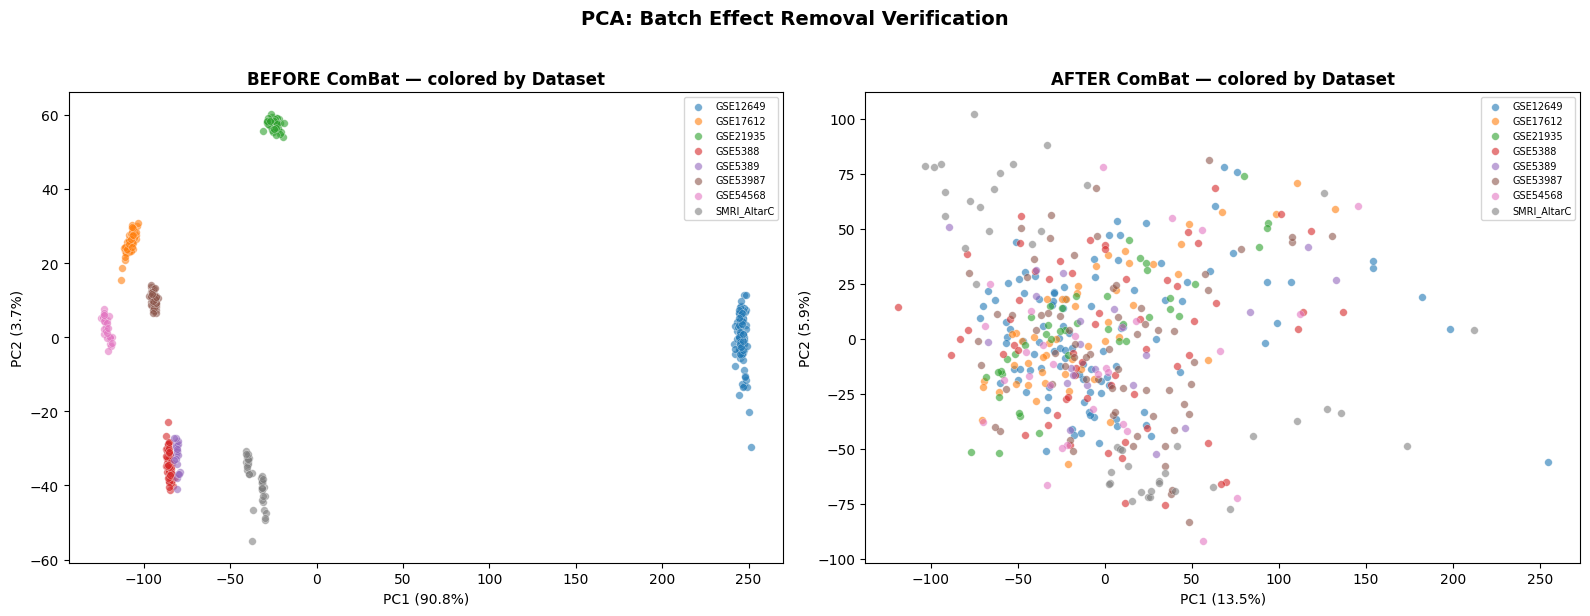

In [24]:
# ---------------------------------------------------------
# Step 6a: PCA BEFORE vs AFTER ComBat — colored by DATASET
# ---------------------------------------------------------

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- PCA BEFORE ComBat ---
scaler_before = StandardScaler()
data_before = scaler_before.fit_transform(merged_expr.T)  # transpose: samples × probes
pca_before = PCA(n_components=2)
pc_before = pca_before.fit_transform(data_before)

# --- PCA AFTER ComBat ---
scaler_after = StandardScaler()
data_after = scaler_after.fit_transform(combat_corrected.T)  # transpose: samples × probes
pca_after = PCA(n_components=2)
pc_after = pca_after.fit_transform(data_after)

# --- Dataset color map ---
dataset_names = sorted(set(batch))
dataset_cmap = plt.cm.tab10
dataset_colors = {ds: dataset_cmap(i) for i, ds in enumerate(dataset_names)}

# --- Plot BEFORE ---
for ds in dataset_names:
    mask = [b == ds for b in batch]
    axes[0].scatter(
        pc_before[mask, 0], pc_before[mask, 1],
        c=[dataset_colors[ds]], label=ds, alpha=0.6, s=30, edgecolors='white', linewidth=0.3
    )
axes[0].set_xlabel(f"PC1 ({pca_before.explained_variance_ratio_[0]*100:.1f}%)")
axes[0].set_ylabel(f"PC2 ({pca_before.explained_variance_ratio_[1]*100:.1f}%)")
axes[0].set_title("BEFORE ComBat — colored by Dataset", fontweight='bold')
axes[0].legend(fontsize=7, loc='best')

# --- Plot AFTER ---
for ds in dataset_names:
    mask = [b == ds for b in batch]
    axes[1].scatter(
        pc_after[mask, 0], pc_after[mask, 1],
        c=[dataset_colors[ds]], label=ds, alpha=0.6, s=30, edgecolors='white', linewidth=0.3
    )
axes[1].set_xlabel(f"PC1 ({pca_after.explained_variance_ratio_[0]*100:.1f}%)")
axes[1].set_ylabel(f"PC2 ({pca_after.explained_variance_ratio_[1]*100:.1f}%)")
axes[1].set_title("AFTER ComBat — colored by Dataset", fontweight='bold')
axes[1].legend(fontsize=7, loc='best')

plt.suptitle("PCA: Batch Effect Removal Verification", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../figures/pca_combat_by_dataset.png', dpi=150, bbox_inches='tight')
plt.show()

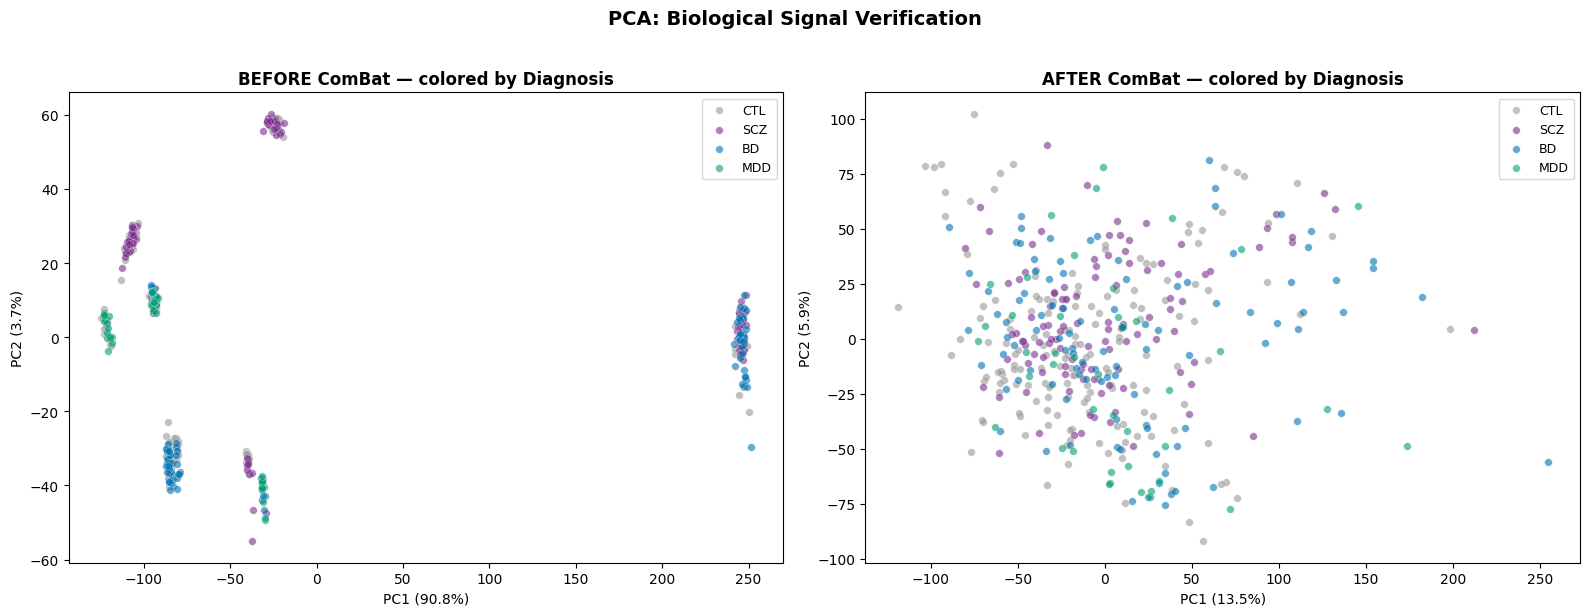

In [25]:
# ---------------------------------------------------------
# Step 6b: PCA AFTER ComBat — colored by DIAGNOSIS
# ---------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Diagnosis colors (same as project palette)
diag_colors = {'SCZ': '#7B2D8E', 'BD': '#0072B2', 'MDD': '#009E73', 'CTL': '#999999'}

# --- Plot BEFORE by diagnosis ---
for dx in ['CTL', 'SCZ', 'BD', 'MDD']:
    mask = [c == dx for c in covariate]
    axes[0].scatter(
        pc_before[mask, 0], pc_before[mask, 1],
        c=diag_colors[dx], label=dx, alpha=0.6, s=30, edgecolors='white', linewidth=0.3
    )
axes[0].set_xlabel(f"PC1 ({pca_before.explained_variance_ratio_[0]*100:.1f}%)")
axes[0].set_ylabel(f"PC2 ({pca_before.explained_variance_ratio_[1]*100:.1f}%)")
axes[0].set_title("BEFORE ComBat — colored by Diagnosis", fontweight='bold')
axes[0].legend(fontsize=9)

# --- Plot AFTER by diagnosis ---
for dx in ['CTL', 'SCZ', 'BD', 'MDD']:
    mask = [c == dx for c in covariate]
    axes[1].scatter(
        pc_after[mask, 0], pc_after[mask, 1],
        c=diag_colors[dx], label=dx, alpha=0.6, s=30, edgecolors='white', linewidth=0.3
    )
axes[1].set_xlabel(f"PC1 ({pca_after.explained_variance_ratio_[0]*100:.1f}%)")
axes[1].set_ylabel(f"PC2 ({pca_after.explained_variance_ratio_[1]*100:.1f}%)")
axes[1].set_title("AFTER ComBat — colored by Diagnosis", fontweight='bold')
axes[1].legend(fontsize=9)

plt.suptitle("PCA: Biological Signal Verification", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../figures/pca_combat_by_diagnosis.png', dpi=150, bbox_inches='tight')
plt.show()


In [26]:
# ---------------------------------------------------------
# Step 6c: Variance explained summary
# ---------------------------------------------------------

print("PCA Variance Explained:")
print(f"\n  BEFORE ComBat:")
print(f"    PC1: {pca_before.explained_variance_ratio_[0]*100:.1f}%")
print(f"    PC2: {pca_before.explained_variance_ratio_[1]*100:.1f}%")
print(f"    Total (PC1+PC2): {sum(pca_before.explained_variance_ratio_[:2])*100:.1f}%")

print(f"\n  AFTER ComBat:")
print(f"    PC1: {pca_after.explained_variance_ratio_[0]*100:.1f}%")
print(f"    PC2: {pca_after.explained_variance_ratio_[1]*100:.1f}%")
print(f"    Total (PC1+PC2): {sum(pca_after.explained_variance_ratio_[:2])*100:.1f}%")

before_total = sum(pca_before.explained_variance_ratio_[:2])*100
after_total = sum(pca_after.explained_variance_ratio_[:2])*100

if after_total < before_total:
    print(f"\n  PC1+PC2 dropped from {before_total:.1f}% to {after_total:.1f}%.")
    print("  This is EXPECTED — batch effects were inflating variance in the top PCs.")
    print("  After removing batch, variance is more evenly distributed across PCs.")
else:
    print(f"\n  PC1+PC2 increased from {before_total:.1f}% to {after_total:.1f}%.")
    print("  Biological signal may now be more prominent in the top PCs.")

PCA Variance Explained:

  BEFORE ComBat:
    PC1: 90.8%
    PC2: 3.7%
    Total (PC1+PC2): 94.5%

  AFTER ComBat:
    PC1: 13.5%
    PC2: 5.9%
    Total (PC1+PC2): 19.4%

  PC1+PC2 dropped from 94.5% to 19.4%.
  This is EXPECTED — batch effects were inflating variance in the top PCs.
  After removing batch, variance is more evenly distributed across PCs.


In [ ]:
## Step 7: Outlier Detection

**Purpose:** Identify and remove samples that are extreme outliers after batch correction. These could be:
- Corrupted or degraded tissue samples
- Mislabeled diagnoses
- Technical failures during microarray processing

**Method:** Using the PCA from Step 6, flag samples that are more than 3 standard deviations from the mean on PC1 or PC2. 
These are samples that behave very differently from all others — even after batch correction.

**Conservative approach:** We only remove clear outliers (>3 SD). Borderline samples are kept to preserve statistical power with our limited sample size (419 samples).
#why Zscore
PCA z-scores win because they handle high-dimensional data, produce a clear visual, use a standard threshold.

In [27]:
# ---------------------------------------------------------
# Step 7a: Detect outliers using PCA distance
# ---------------------------------------------------------

# Use the post-ComBat PCA scores from Step 6
pc1 = pc_after[:, 0]
pc2 = pc_after[:, 1]

# Calculate z-scores for PC1 and PC2
pc1_z = (pc1 - pc1.mean()) / pc1.std()
pc2_z = (pc2 - pc2.mean()) / pc2.std()

# Flag samples beyond 3 SD on either PC
threshold = 3
outlier_mask = (np.abs(pc1_z) > threshold) | (np.abs(pc2_z) > threshold)

# Get outlier details
outlier_samples = merged_expr.columns[outlier_mask]
n_outliers = outlier_mask.sum()

print(f"Outlier detection (threshold: >{threshold} SD on PC1 or PC2)")
print(f"{'='*55}")
print(f"Total samples: {len(outlier_mask)}")
print(f"Outliers found: {n_outliers}")
print(f"Clean samples: {len(outlier_mask) - n_outliers}")

if n_outliers > 0:
    print(f"\nOutlier details:")
    print(f"{'Sample':<15} {'Dataset':<15} {'Diagnosis':<8} {'PC1_z':>8} {'PC2_z':>8}")
    print("-" * 55)
    for i, is_outlier in enumerate(outlier_mask):
        if is_outlier:
            sid = merged_expr.columns[i]
            ds = batch[i]
            dx = covariate[i]
            print(f"{sid:<15} {ds:<15} {dx:<8} {pc1_z[i]:>+8.2f} {pc2_z[i]:>+8.2f}")

Outlier detection (threshold: >3 SD on PC1 or PC2)
Total samples: 419
Outliers found: 5
Clean samples: 414

Outlier details:
Sample          Dataset         Diagnosis    PC1_z    PC2_z
-------------------------------------------------------
GSM317411       GSE12649        BD          +3.33    +0.53
GSM317433       GSE12649        BD          +4.65    -1.54
GSM317441       GSE12649        CTL         +3.62    +0.13
C-18            SMRI_AltarC     SCZ         +3.88    +0.11
C-41            SMRI_AltarC     MDD         +3.18    -1.34


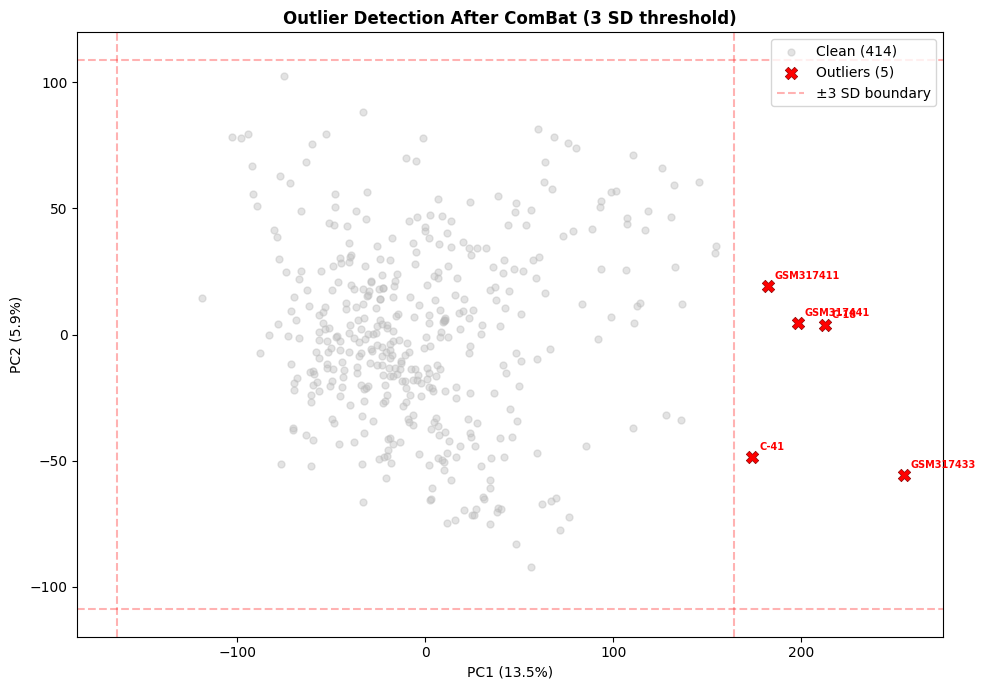

In [29]:
# ---------------------------------------------------------
# Step 7b: Visualize outliers on PCA plot
# ---------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 7))

# Plot clean samples (gray)
clean_mask = ~outlier_mask
ax.scatter(
    pc_after[clean_mask, 0], pc_after[clean_mask, 1],
    c='#BBBBBB', alpha=0.4, s=25, label=f'Clean ({clean_mask.sum()})'
)

# Plot outliers (red)
if n_outliers > 0:
    ax.scatter(
        pc_after[outlier_mask, 0], pc_after[outlier_mask, 1],
        c='red', s=80, marker='X', edgecolors='darkred', linewidth=0.5,
        label=f'Outliers ({n_outliers})', zorder=5
    )
    # Label each outlier
    for i, is_outlier in enumerate(outlier_mask):
        if is_outlier:
            ax.annotate(
                merged_expr.columns[i],
                (pc_after[i, 0], pc_after[i, 1]),
                fontsize=7, color='red', fontweight='bold',
                xytext=(5, 5), textcoords='offset points'
            )

# Draw threshold boundaries
pc1_boundary = threshold * pc1.std() + pc1.mean()
pc1_boundary_neg = -threshold * pc1.std() + pc1.mean()
pc2_boundary = threshold * pc2.std() + pc2.mean()
pc2_boundary_neg = -threshold * pc2.std() + pc2.mean()

ax.axvline(pc1_boundary, color='red', linestyle='--', alpha=0.3, label=f'±{threshold} SD boundary')
ax.axvline(pc1_boundary_neg, color='red', linestyle='--', alpha=0.3)
ax.axhline(pc2_boundary, color='red', linestyle='--', alpha=0.3)
ax.axhline(pc2_boundary_neg, color='red', linestyle='--', alpha=0.3)

ax.set_xlabel(f"PC1 ({pca_after.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca_after.explained_variance_ratio_[1]*100:.1f}%)")
ax.set_title("Outlier Detection After ComBat (3 SD threshold)", fontweight='bold')
ax.legend(loc='best')
plt.tight_layout()
plt.savefig('../figures/pca_outlier_detection.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
### Outlier Visualization

The plot below shows all 419 samples projected onto PC1 and PC2 after ComBat batch correction. The red dashed lines mark the ±3 standard deviation boundaries. 
Samples beyond these boundaries (red X markers) are flagged as outliers.

**5 outliers detected — all extreme on PC1 (positive direction):**
- 3 from GSE12649 (GPL96 platform): GSM317411 (BD), GSM317433 (BD), GSM317441 (CTL)
- 2 from SMRI_AltarC (GPL96 platform): C-18 (SCZ), C-41 (MDD)

All 5 outliers come from GPL96 platform datasets and are shifted in the same direction, suggesting a shared technical issue 
(possibly RNA degradation or poor hybridization quality) that ComBat could not fully correct.

**Impact on class balance after removal (419 → 414 samples):**
- SCZ: 112 → 111
- BD: 101 → 99
- MDD: 43 → 42
- CTL: 163 → 162

The loss is minimal and evenly distributed across classes, no single diagnosi

In [30]:
# ---------------------------------------------------------
# Step 7c: Remove outliers
# ---------------------------------------------------------

if n_outliers > 0:
    # Remove from expression data
    clean_cols = [col for col in combat_corrected.columns if col not in outlier_samples]
    combat_clean = combat_corrected[clean_cols]
    
    # Remove from metadata
    meta_clean = meta_df[~meta_df['sample_id'].isin(outlier_samples)].reset_index(drop=True)
    
    print(f"Removed {n_outliers} outlier(s).")
    print(f"\nBefore: {combat_corrected.shape[0]:,} probes × {combat_corrected.shape[1]} samples")
    print(f"After:  {combat_clean.shape[0]:,} probes × {combat_clean.shape[1]} samples")
    
    print(f"\nRemaining samples per diagnosis:")
    print(meta_clean['diagnosis'].value_counts().to_string())
    
    print(f"\nRemaining samples per dataset:")
    print(meta_clean['dataset'].value_counts().to_string())
else:
    combat_clean = combat_corrected.copy()
    meta_clean = meta_df.copy()
    print("No outliers detected. All 419 samples retained.")
    print(f"\nShape: {combat_clean.shape[0]:,} probes × {combat_clean.shape[1]} samples")

Removed 5 outlier(s).

Before: 22,277 probes × 419 samples
After:  22,277 probes × 414 samples

Remaining samples per diagnosis:
diagnosis
CTL    162
SCZ    111
BD      99
MDD     42

Remaining samples per dataset:
dataset
GSE12649       99
GSE53987       68
GSE5388        61
GSE17612       51
GSE21935       42
SMRI_AltarC    42
GSE54568       30
GSE5389        21


In [ ]:
## Step 8: Low-Variance Probe Filtering

After ComBat and outlier removal, we have 22,277 probes. Many of these are uninformative — housekeeping genes that maintain the same expression level regardless of diagnosis, or probes measuring background noise.

A probe that reads ~6.2 in every single sample — whether SCZ, BD, MDD, or CTL — tells the classifier nothing. It adds a feature dimension without adding any discriminatory power. Keeping it only slows training and increases the risk of overfitting.

**What we do:** Calculate the variance of each probe across all 414 samples. Probes in the bottom 10% of variance are removed. These are the flattest, least informative features in the dataset.

**What we keep:** The top 90% — probes that show meaningful variation across samples, which could reflect biological differences between psychiatric conditions.

Probe variance summary (22,277 probes):
  Min:    0.0194
  5th %:  0.0575
  10th %: 0.0701
  25th %: 0.1059
  Median: 0.2055
  75th %: 0.4011
  Max:    7.6948


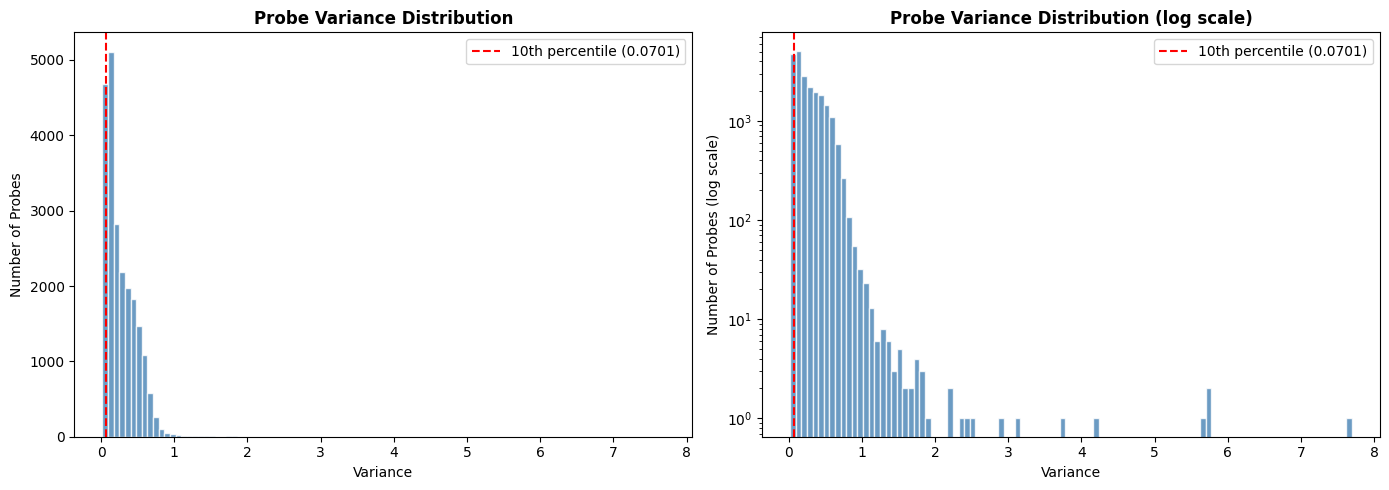

Saved: ../figures/probe_variance_distribution.png


In [31]:
# ---------------------------------------------------------
# Step 8a: Calculate probe variance and explore distribution
# ---------------------------------------------------------

# Calculate variance of each probe across all 414 samples
probe_variance = combat_clean.var(axis=1)

print(f"Probe variance summary ({combat_clean.shape[0]:,} probes):")
print(f"  Min:    {probe_variance.min():.4f}")
print(f"  5th %:  {probe_variance.quantile(0.05):.4f}")
print(f"  10th %: {probe_variance.quantile(0.10):.4f}")
print(f"  25th %: {probe_variance.quantile(0.25):.4f}")
print(f"  Median: {probe_variance.median():.4f}")
print(f"  75th %: {probe_variance.quantile(0.75):.4f}")
print(f"  Max:    {probe_variance.max():.4f}")

# Plot variance distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(probe_variance, bins=100, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(probe_variance.quantile(0.10), color='red', linestyle='--', 
                label=f'10th percentile ({probe_variance.quantile(0.10):.4f})')
axes[0].set_xlabel('Variance')
axes[0].set_ylabel('Number of Probes')
axes[0].set_title('Probe Variance Distribution', fontweight='bold')
axes[0].legend()

# Log-scale histogram (easier to see the low-variance tail)
axes[1].hist(probe_variance, bins=100, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].axvline(probe_variance.quantile(0.10), color='red', linestyle='--',
                label=f'10th percentile ({probe_variance.quantile(0.10):.4f})')
axes[1].set_xlabel('Variance')
axes[1].set_ylabel('Number of Probes (log scale)')
axes[1].set_yscale('log')
axes[1].set_title('Probe Variance Distribution (log scale)', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('../figures/probe_variance_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: ../figures/probe_variance_distribution.png")

In [32]:
# ---------------------------------------------------------
# Step 8b: Filter low-variance probes
# ---------------------------------------------------------

# Remove bottom 10% of probes by variance
variance_threshold = probe_variance.quantile(0.10)
high_var_mask = probe_variance >= variance_threshold

combat_filtered = combat_clean.loc[high_var_mask]

probes_removed = combat_clean.shape[0] - combat_filtered.shape[0]
probes_kept = combat_filtered.shape[0]

print(f"Low-variance probe filtering (threshold: bottom 10%)")
print(f"{'='*50}")
print(f"Variance threshold: {variance_threshold:.4f}")
print(f"Probes before: {combat_clean.shape[0]:,}")
print(f"Probes removed: {probes_removed:,} ({probes_removed/combat_clean.shape[0]*100:.1f}%)")
print(f"Probes kept:    {probes_kept:,} ({probes_kept/combat_clean.shape[0]*100:.1f}%)")
print(f"\nFinal shape: {combat_filtered.shape[0]:,} probes × {combat_filtered.shape[1]} samples")

Low-variance probe filtering (threshold: bottom 10%)
Variance threshold: 0.0701
Probes before: 22,277
Probes removed: 2,228 (10.0%)
Probes kept:    20,049 (90.0%)

Final shape: 20,049 probes × 414 samples


In [33]:
# ---------------------------------------------------------
# Step 8c: Before/after comparison — variance range
# ---------------------------------------------------------

probe_var_after = combat_filtered.var(axis=1)

print(f"Variance range BEFORE filtering: [{probe_variance.min():.4f}, {probe_variance.max():.4f}]")
print(f"Variance range AFTER filtering:  [{probe_var_after.min():.4f}, {probe_var_after.max():.4f}]")
print(f"\nThe lowest-variance probes have been removed.")
print(f"All remaining {combat_filtered.shape[0]:,} probes have variance ≥ {variance_threshold:.4f}")

Variance range BEFORE filtering: [0.0194, 7.6948]
Variance range AFTER filtering:  [0.0701, 7.6948]

The lowest-variance probes have been removed.
All remaining 20,049 probes have variance ≥ 0.0701


In [ ]:
## Step 9: Transpose to ML Format

All filtering is complete. We now flip the DataFrame from genomics format (probes × samples) 
to standard machine learning format (samples × features), and attach the diagnosis labels.

- **Before:** 20,049 rows (probes) × 414 columns (samples)
- **After:** 414 rows (samples) × 20,049 columns (probes) + 1 diagnosis column

In [75]:
meta_rows = []

for _, row in meta_clean.iterrows():
    sid = row['sample_id']
    ds = row['dataset']
    new_row = row.to_dict()
    
    if ds == 'GSE53987':
        i = all_meta['GSE53987']['sample_ids'].index(sid)
        new_row['age'] = all_meta['GSE53987']['age'][i]
        new_row['sex'] = all_meta['GSE53987']['gender'][i]
        new_row['brain_region'] = all_meta['GSE53987']['tissue'][i]
        new_row['ph'] = all_meta['GSE53987']['ph'][i]
        new_row['pmi'] = all_meta['GSE53987']['pmi'][i]
    elif ds == 'GSE17612':
        i = all_meta['GSE17612']['sample_ids'].index(sid)
        new_row['age'] = all_meta['GSE17612']['age'][i]
        new_row['sex'] = all_meta['GSE17612']['gender'][i]
        new_row['brain_region'] = 'PFC (BA10)'
        new_row['ph'] = all_meta['GSE17612']['ph'][i]
        new_row['pmi'] = all_meta['GSE17612']['post-mortem delay'][i]
    elif ds == 'GSE21935':
        i = all_meta['GSE21935']['sample_ids'].index(sid)
        new_row['age'] = all_meta['GSE21935']['age'][i]
        new_row['sex'] = all_meta['GSE21935']['gender'][i]
        new_row['brain_region'] = 'BA22'
        new_row['ph'] = all_meta['GSE21935']['ph'][i]
        new_row['pmi'] = all_meta['GSE21935']['post-mortem delay'][i]
    elif ds == 'GSE54568':
        new_row['age'] = None
        new_row['sex'] = None
        new_row['brain_region'] = 'PFC (BA9)'
        new_row['ph'] = None
        new_row['pmi'] = None
    elif ds == 'GSE12649':
        new_row['age'] = None
        new_row['sex'] = None
        new_row['brain_region'] = 'PFC (BA46)'
        new_row['ph'] = None
        new_row['pmi'] = None
    elif ds == 'GSE5388':
        i = all_meta['GSE5388']['sample_ids'].index(sid)
        new_row['age'] = all_meta['GSE5388']['Age (years)'][i]
        new_row['sex'] = all_meta['GSE5388']['Gender'][i]
        new_row['brain_region'] = 'PFC (BA46)'
        new_row['ph'] = all_meta['GSE5388']['Brain pH'][i]
        new_row['pmi'] = all_meta['GSE5388']['Post mortem interval (hours)'][i]
    elif ds == 'GSE5389':
        i = all_meta['GSE5389']['sample_ids'].index(sid)
        new_row['age'] = all_meta['GSE5389']['Age (years)'][i]
        new_row['sex'] = all_meta['GSE5389']['Gender'][i]
        new_row['brain_region'] = 'OFC (BA11)'
        new_row['ph'] = all_meta['GSE5389']['Brain pH'][i]
        new_row['pmi'] = all_meta['GSE5389']['Post mortem interval (hours)'][i]
    elif ds == 'SMRI_AltarC':
        i = all_meta['SMRI_AltarC']['sample_ids'].index(sid)
        new_row['age'] = all_meta['SMRI_AltarC']['diagnosis']  # wrong key, fix below
        new_row['sex'] = None
        new_row['brain_region'] = 'PFC (BA46)'
        new_row['ph'] = None
        new_row['pmi'] = None
    
    meta_rows.append(new_row)

meta_clean = pd.DataFrame(meta_rows)
meta_clean.shape, meta_clean.columns.tolist()

((414, 9),
 ['sample_id',
  'dataset',
  'platform',
  'diagnosis',
  'age',
  'sex',
  'brain_region',
  'ph',
  'pmi'])

In [76]:
meta_clean[meta_clean['dataset'] == 'SMRI_AltarC'][['sample_id', 'age', 'sex', 'ph', 'pmi']].head()

,sample_id,age,sex,ph,pmi
372,C-1,"[SCHIZ UNDIFF, DEPRESSIVE DISORDER, SCHIZ PARA...",None,None,None
373,C-2,"[SCHIZ UNDIFF, DEPRESSIVE DISORDER, SCHIZ PARA...",None,None,None
374,C-3,"[SCHIZ UNDIFF, DEPRESSIVE DISORDER, SCHIZ PARA...",None,None,None
375,C-4,"[SCHIZ UNDIFF, DEPRESSIVE DISORDER, SCHIZ PARA...",None,None,None
376,C-5,"[SCHIZ UNDIFF, DEPRESSIVE DISORDER, SCHIZ PARA...",None,None,None


In [77]:
for i, sid in enumerate(all_meta['SMRI_AltarC']['sample_ids']):
    if sid in meta_clean['sample_id'].values:
        idx = meta_clean[meta_clean['sample_id'] == sid].index[0]
        meta_clean.loc[idx, 'age'] = demo.loc[i, 'Age']
        meta_clean.loc[idx, 'sex'] = demo.loc[i, 'Sex']
        meta_clean.loc[idx, 'ph'] = demo.loc[i, 'Brain_PH']
        meta_clean.loc[idx, 'pmi'] = demo.loc[i, 'PMI']

meta_clean[meta_clean['dataset'] == 'SMRI_AltarC'][['sample_id', 'age', 'sex', 'ph', 'pmi']].head()

,sample_id,age,sex,ph,pmi
372,C-1,30,F,6.2,60
373,C-2,30,F,6.0,47
374,C-3,50,M,6.0,61
375,C-4,30,M,5.8,32
376,C-5,25,F,6.4,24


In [78]:
# Standardize sex
meta_clean['sex'] = meta_clean['sex'].replace({
    'Male': 'M', 'male': 'M', 'Female': 'F', 'female': 'F'
})

# Clean PMI
meta_clean['pmi'] = meta_clean['pmi'].astype(str).str.replace('h', '').str.strip()
meta_clean['pmi'] = pd.to_numeric(meta_clean['pmi'], errors='coerce')

# Convert age and ph to numeric
meta_clean['age'] = pd.to_numeric(meta_clean['age'], errors='coerce')
meta_clean['ph'] = pd.to_numeric(meta_clean['ph'], errors='coerce')

meta_clean['sex'].value_counts(dropna=False)

sex
M       169
None    129
F       115
91        1
Name: count, dtype: int64

In [79]:
bad_idx = meta_clean[meta_clean['sex'] == '91'].index[0]
meta_clean.loc[bad_idx, 'age'] = 91
meta_clean.loc[bad_idx, 'sex'] = 'M'
meta_clean.loc[bad_idx, 'ph'] = 6.3
meta_clean.loc[bad_idx, 'pmi'] = np.nan

meta_clean.loc[bad_idx]

sample_id        GSM439788
dataset           GSE17612
platform            GPL570
diagnosis              CTL
age                   91.0
sex                      M
brain_region    PFC (BA10)
ph                     6.3
pmi                    NaN
Name: 78, dtype: object

In [80]:
# ---------------------------------------------------------
# Step 9: Transpose and attach metadata
# ---------------------------------------------------------
df_ml = combat_filtered.T.copy()
df_ml.index.name = 'sample_id'

# Merge with all metadata
meta_indexed = meta_clean.set_index('sample_id')
df_ml = df_ml.join(meta_indexed)

df_ml.shape, df_ml[['diagnosis', 'brain_region', 'dataset', 'age', 'sex', 'ph', 'pmi']].head()

((414, 20057),
            diagnosis               brain_region   dataset   age sex   ph   pmi
 sample_id                                                                     
 GSM1304920        BD  Pre-frontal cortex (BA46)  GSE53987  52.0   M  6.7  23.5
 GSM1304921        BD  Pre-frontal cortex (BA46)  GSE53987  50.0   F  6.4  11.7
 GSM1304922        BD  Pre-frontal cortex (BA46)  GSE53987  28.0   F  6.3  22.3
 GSM1304923        BD  Pre-frontal cortex (BA46)  GSE53987  55.0   F  6.4  17.5
 GSM1304924        BD  Pre-frontal cortex (BA46)  GSE53987  58.0   M  6.8  27.7)

In [81]:
# Check what columns are in meta_clean
print("Metadata columns:", meta_clean.columns.tolist())
print(f"\nFirst 5 rows:")
print(meta_clean.head())

Metadata columns: ['sample_id', 'dataset', 'platform', 'diagnosis', 'age', 'sex', 'brain_region', 'ph', 'pmi']

First 5 rows:
    sample_id   dataset platform diagnosis   age sex  \
0  GSM1304920  GSE53987   GPL570        BD  52.0   M   
1  GSM1304921  GSE53987   GPL570        BD  50.0   F   
2  GSM1304922  GSE53987   GPL570        BD  28.0   F   
3  GSM1304923  GSE53987   GPL570        BD  55.0   F   
4  GSM1304924  GSE53987   GPL570        BD  58.0   M   

                brain_region   ph   pmi  
0  Pre-frontal cortex (BA46)  6.7  23.5  
1  Pre-frontal cortex (BA46)  6.4  11.7  
2  Pre-frontal cortex (BA46)  6.3  22.3  
3  Pre-frontal cortex (BA46)  6.4  17.5  
4  Pre-frontal cortex (BA46)  6.8  27.7  


In [ ]:
# ---------------------------------------------------------
# EDA: Shape and structure
# ---------------------------------------------------------

In [82]:
df_ml.shape

(414, 20057)

In [84]:
df_ml.describe()

,1007_s_at,1053_at,117_at,1255_g_at,1294_at,1316_at,1320_at,1405_i_at,1431_at,1438_at,...,AFFX-r2-P1-cre-5_at,AFFX-ThrX-3_at,AFFX-ThrX-5_at,AFFX-ThrX-M_at,AFFX-TrpnX-3_at,AFFX-TrpnX-5_at,AFFX-TrpnX-M_at,age,ph,pmi
count,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000,...,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000,285.000000,284.000000,284.000000
mean,7.962666,4.320223,3.781929,3.187460,4.616089,4.553380,2.039207,1.094676,3.553827,4.134646,...,11.677316,2.442341,2.258139,2.185985,0.980393,1.308633,0.685403,53.329825,6.408838,21.100634
std,0.350765,0.344411,0.709943,0.543423,0.278959,0.288567,0.535124,0.556407,0.343919,0.635394,...,0.301193,0.520089,0.746998,0.689707,0.722591,0.700447,0.472743,18.188276,0.309471,14.625553
min,6.881548,2.974470,2.089435,0.722265,3.792401,3.499012,0.285106,-0.398030,2.386330,1.667945,...,10.690782,0.441198,0.088978,-0.640102,-1.013586,-0.581855,-0.484465,19.000000,5.700000,3.000000
25%,7.731241,4.122461,3.494794,2.904077,4.425892,4.353333,1.699161,0.736083,3.345453,3.770554,...,11.481011,2.178628,1.689660,1.752260,0.539879,0.769124,0.387281,41.000000,6.200000,11.000000
50%,7.953509,4.349206,3.695241,3.184969,4.624707,4.556849,2.028606,1.041097,3.573149,4.194729,...,11.653715,2.383636,2.211506,2.084316,0.945977,1.315630,0.626972,50.000000,6.400000,19.000000
75%,8.198323,4.564073,3.953797,3.494430,4.795332,4.745085,2.356393,1.365413,3.786980,4.575108,...,11.875105,2.681753,2.832695,2.698636,1.445653,1.796622,0.919788,65.000000,6.600000,28.000000
max,9.024451,5.449085,9.225802,6.125845,5.443507,5.540747,3.813615,3.170198,4.601420,5.906092,...,12.507787,5.595115,4.241542,5.345281,3.168320,3.562315,3.684150,97.000000,7.300000,84.000000


In [85]:
(df_ml.columns[:10].tolist())

['1007_s_at',
 '1053_at',
 '117_at',
 '1255_g_at',
 '1294_at',
 '1316_at',
 '1320_at',
 '1405_i_at',
 '1431_at',
 '1438_at']

In [86]:
df_ml.dtypes.value_counts()

float64    20052
object         5
Name: count, dtype: int64

In [87]:
# ---------------------------------------------------------
# EDA: Target variable
# ---------------------------------------------------------

df_ml['diagnosis'].value_counts()

diagnosis
CTL    162
SCZ    111
BD      99
MDD     42
Name: count, dtype: int64

In [88]:

df_ml['diagnosis'].value_counts(normalize=True).round(3)

diagnosis
CTL    0.391
SCZ    0.268
BD     0.239
MDD    0.101
Name: proportion, dtype: float64

In [89]:
df_ml.isna().sum().sum()

518

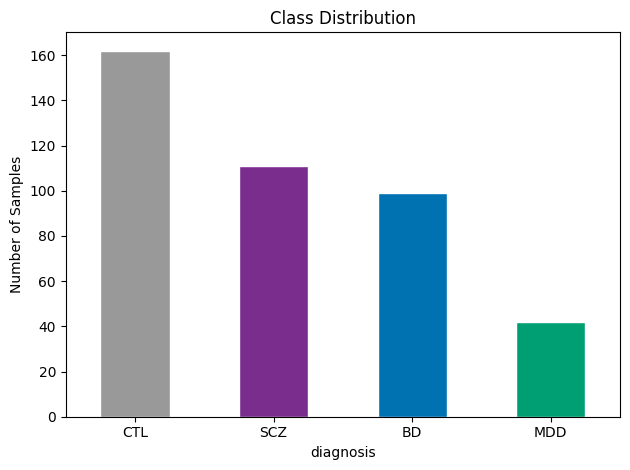

In [90]:
# Class distribution bar plot
df_ml['diagnosis'].value_counts().plot(kind='bar', color=['#999999', '#7B2D8E', '#0072B2', '#009E73'],
                                        edgecolor='white')
plt.ylabel('Number of Samples')
plt.title('Class Distribution')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../figures/eda_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

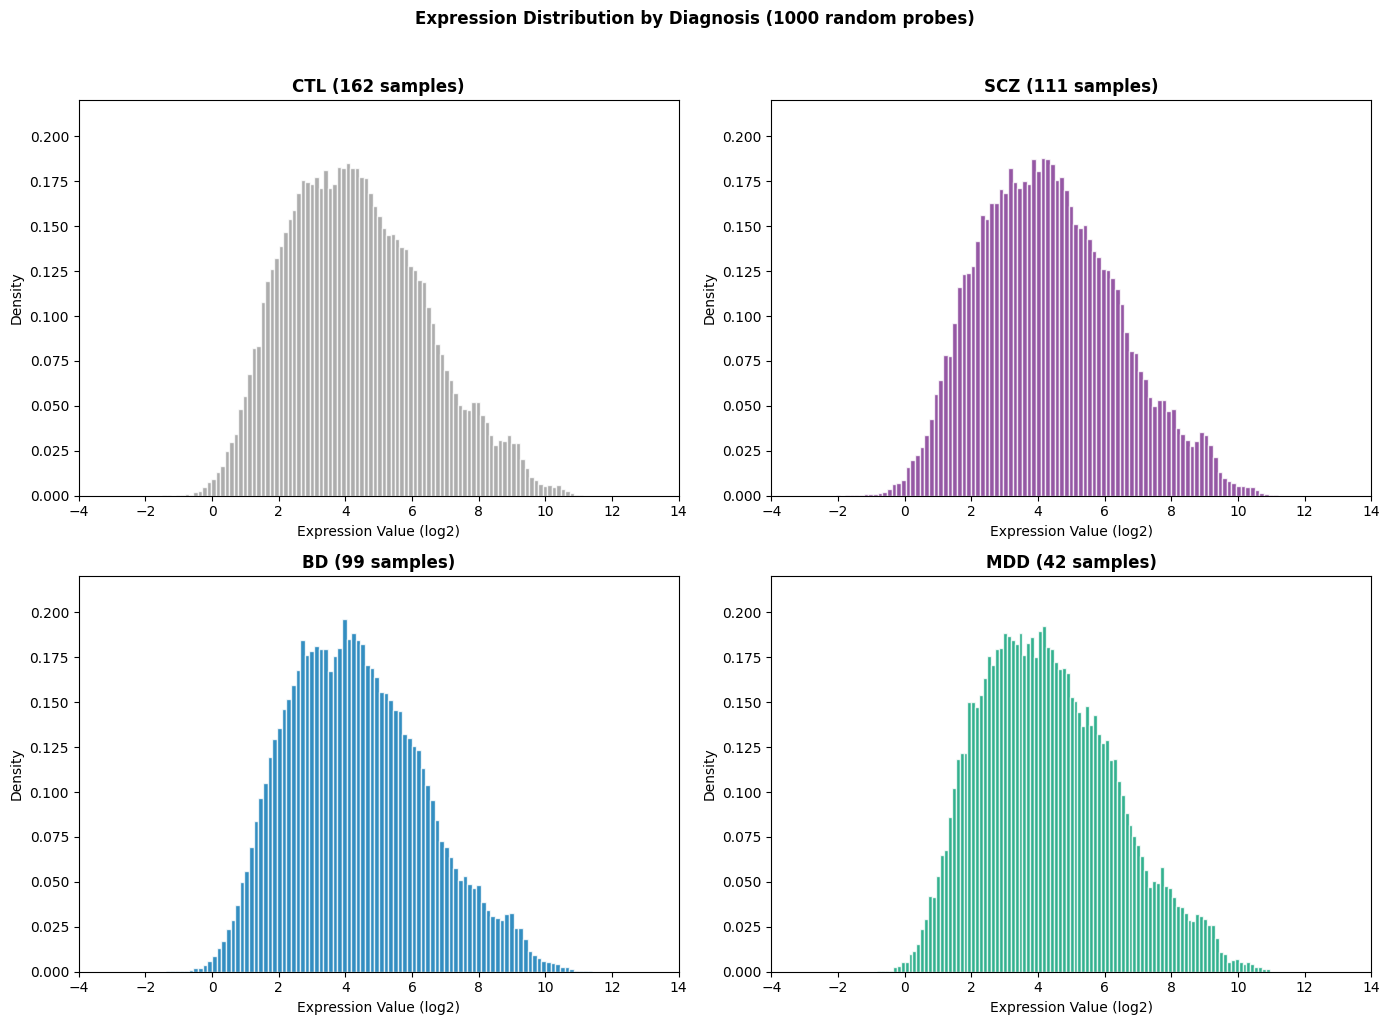

In [68]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

np.random.seed(42)
random_probes = np.random.choice(df_ml.columns[1:], size=1000, replace=False)
colors = {'CTL': '#999999', 'SCZ': '#7B2D8E', 'BD': '#0072B2', 'MDD': '#009E73'}

# One subplot per diagnosis — easier to see differences
for ax, dx in zip(axes.flatten(), ['CTL', 'SCZ', 'BD', 'MDD']):
    vals = df_ml[df_ml['diagnosis'] == dx][random_probes].values.flatten()
    ax.hist(vals, bins=100, color=colors[dx], edgecolor='white', alpha=0.8, density=True)
    ax.set_title(f"{dx} ({(df_ml['diagnosis']==dx).sum()} samples)", fontweight='bold')
    ax.set_xlabel('Expression Value (log2)')
    ax.set_ylabel('Density')
    ax.set_xlim(-4, 14)
    ax.set_ylim(0, 0.22)

plt.suptitle('Expression Distribution by Diagnosis (1000 random probes)', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../figures/eda_expression_by_diagnosis.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
### Expression Distribution by Diagnosis
Comparing the overall gene expression distribution across the four diagnosis groups. 
Similar shapes confirm ComBat harmonization worked — no group is on a different scale. 
Differences between diagnoses are subtle and spread across individual probes, not visible in the bulk distribution.

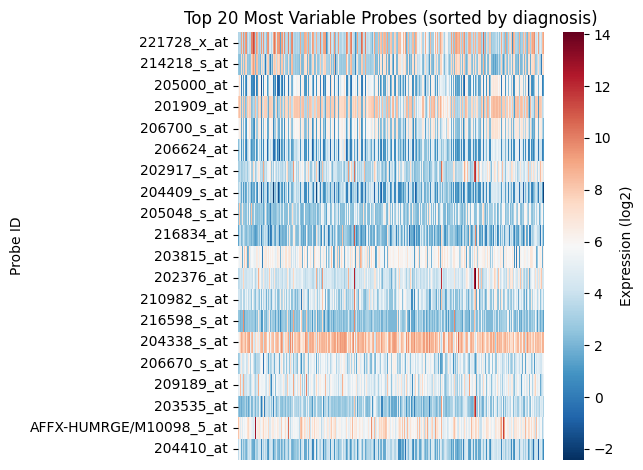

In [69]:
# Top 20 most variable probes — heatmap
probe_cols = df_ml.columns[1:]
top20 = df_ml[probe_cols].var().nlargest(20).index.tolist()

df_sorted = df_ml.sort_values('diagnosis')
sns.heatmap(df_sorted[top20].T, cmap='RdBu_r', xticklabels=False,
            cbar_kws={'label': 'Expression (log2)'})
plt.title('Top 20 Most Variable Probes (sorted by diagnosis)')
plt.ylabel('Probe ID')
plt.tight_layout()
plt.savefig('../figures/eda_top20_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
### Top 20 Most Variable Probes — Heatmap
The 20 probes with the highest variance across all 414 samples, with samples sorted by diagnosis (BD → CTL → MDD → SCZ). 
Subtle color shifts across diagnosis groups suggest potential discriminatory signal that the classifier may exploit.

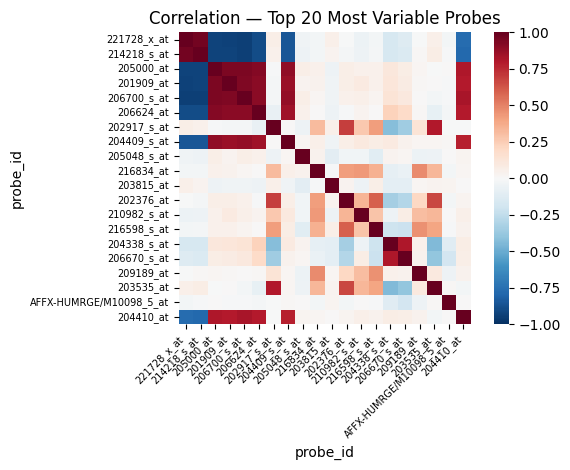

In [70]:
# Correlation between top 20 probes
sns.heatmap(df_ml[top20].corr(), cmap='RdBu_r', center=0, vmin=-1, vmax=1, square=True)
plt.title('Correlation — Top 20 Most Variable Probes')
plt.xticks(fontsize=7, rotation=45, ha='right')
plt.yticks(fontsize=7)
plt.tight_layout()
plt.savefig('../figures/eda_top20_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
### Correlation Between Top Variable Probes
Examining relationships between the top 20 probes. 
Clusters of positively correlated probes likely belong to the same biological pathway. 
Negatively correlated pairs are especially valuable — they give the classifier two opposing signals.

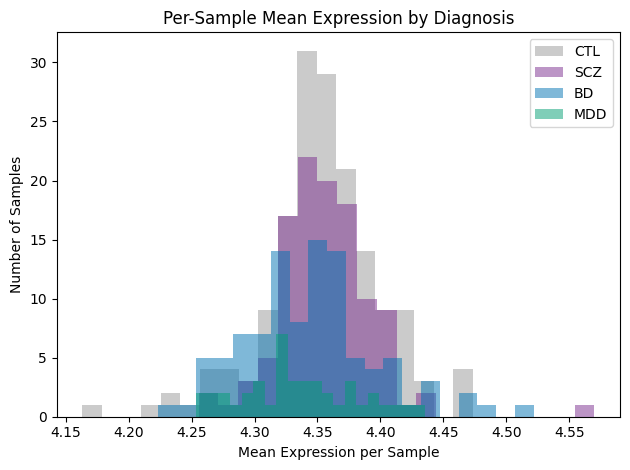

In [71]:
# Per-sample mean expression by diagnosis
sample_means = df_ml[probe_cols].mean(axis=1)

for dx in ['CTL', 'SCZ', 'BD', 'MDD']:
    mask = df_ml['diagnosis'] == dx
    plt.hist(sample_means[mask], bins=20, alpha=0.5, label=dx, color=colors[dx])

plt.xlabel('Mean Expression per Sample')
plt.ylabel('Number of Samples')
plt.title('Per-Sample Mean Expression by Diagnosis')
plt.legend()
plt.tight_layout()
plt.savefig('../figures/eda_sample_means.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
### Per-Sample Mean Expression by Diagnosis
All four groups center around 4.30–4.40, confirming ComBat successfully harmonized the data. 
The tight range shows no diagnosis group is systematically higher or lower. 
BD shows slightly more spread, possibly reflecting its known biological heterogeneity.